In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


In [8]:
img_path = "../data/Robotic/Distance_Z_Axis/Image2024-08-29_11-22-56.png"

img = cv2.imread(img_path)

16929.5
Coordinates of the center for the largest contour: (1591, 568)


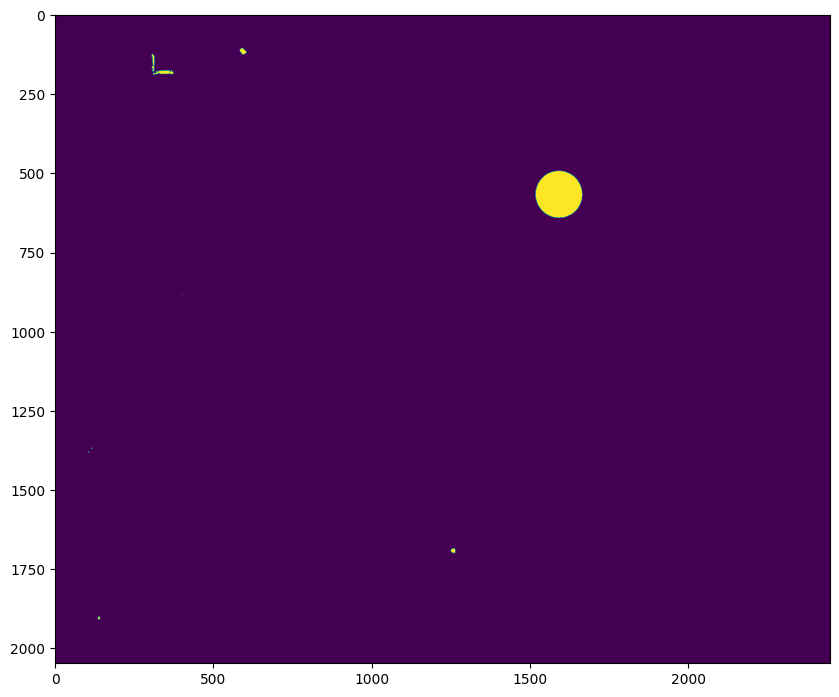

In [9]:
x, y = 0, 0
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(img_gray, 120, 255, cv2.THRESH_BINARY_INV)

# detect the contours on the binary image using cv2.CHAIN_APPROX_NONE
contours, hierarchy = cv2.findContours(image=thresh, mode=cv2.RETR_TREE, 
                                    method=cv2.CHAIN_APPROX_NONE)

area_list = []
for contour in contours:
    # draw contours on the original image
    image_copy = img.copy()
    area = cv2.contourArea(contour)
    area_list.append(area)
    # print(area)
max_area = max(area_list)
print(max_area)

# Find the contour that corresponds to the maximum area
max_contour = contours[area_list.index(max_area)]

# Calculate the center of the maximum area contour
M = cv2.moments(max_contour)
if M['m00'] != 0:
    cx = int(M['m10'] / M['m00'])
    cy = int(M['m01'] / M['m00'])
    print(f"Coordinates of the center for the largest contour: ({cx}, {cy})")
    cv2.circle(image_copy, (cx, cy), radius=5, color=(0, 255,0), thickness=1)
else:
    print("Could not find the center coordinates for the largest contour.")


if 1000 < area < 100000:
    cv2.drawContours(image_copy, contours=contour, contourIdx=-1, 
                    color=(255, 255, 0), thickness=2, lineType=cv2.LINE_AA)

# image_copy = cv2.putText(image_copy, ".", (int(x), int(y)), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), thickness = 2, lineType=cv2.LINE_AA)
plt.figure(figsize=(10, 10))
plt.imshow(thresh)


In [10]:
def distanceCameraToObject(x1_dis, x2_dis, focal_length, baseLine):
    pixel_focalLength = focal_length * 1000 / 3.45
    dis_cameraToObject = baseLine * pixel_focalLength / (abs(x1_dis - x2_dis))
    return dis_cameraToObject, pixel_focalLength

# xy1 = [1564, 601]
# xy2 = [1557, 1547]


xy1 = [1571, 1568]
xy2 = [1579, 583]

xy1 = (1583, 1587)
xy2 = (1591, 568)

dis_cameraToObject, pixel_focalLength = distanceCameraToObject(xy1[1], xy2[1], 16, 130)

print(dis_cameraToObject)


591.6570664618623
